<a href="https://colab.research.google.com/github/blairelep22/DexcomAIPrototype/blob/dex.ipynb/dexcomgenaiproto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from io import StringIO
from datetime import datetime
import matplotlib.pyplot as plt


The following is a sample of cleaned up data taken from dexcom and garmin health sleep tracking. To make this more steamlined - a better use case would be someone that has health data all in one app like apple health connected with dexcom.

In [2]:
csv_data = """
timestamp,glucose_mg_dL,insulin_units,insulin_type,meal,exercise,note
2025-04-15 07:30,110,8,basal,none,none,Woke up
2025-04-15 08:15,145,3,bolus,breakfast,none,Oatmeal and banana
2025-04-15 09:45,160,0,,none,walk,Walked 20 minutes
2025-04-15 11:00,130,0,,none,none,
2025-04-15 12:15,180,4,bolus,lunch,none,Had rice and grilled chicken
2025-04-15 13:30,170,0,,none,walk,Light walk
2025-04-15 15:00,150,0,,none,none,Felt sleepy
2025-04-15 17:30,190,5,bolus,dinner,none,Pasta and garlic bread
2025-04-15 18:30,175,0,,none,walk,Evening walk
2025-04-15 20:30,140,0,,snack,none,Small yogurt
2025-04-15 22:00,120,2,basal,none,none,Bedtime dose
2025-04-16 02:30,95,0,,none,none,Woke up briefly
2025-04-16 07:30,105,8,basal,none,none,Woke up
2025-04-16 08:00,140,3,bolus,breakfast,none,Eggs and toast
"""

🔍 Basic Summary by Day:

           glucose_mg_dL           insulin_units
                    mean  max  min           sum
date                                            
2025-04-15    151.818182  190  110            22
2025-04-16    113.333333  140   95            11


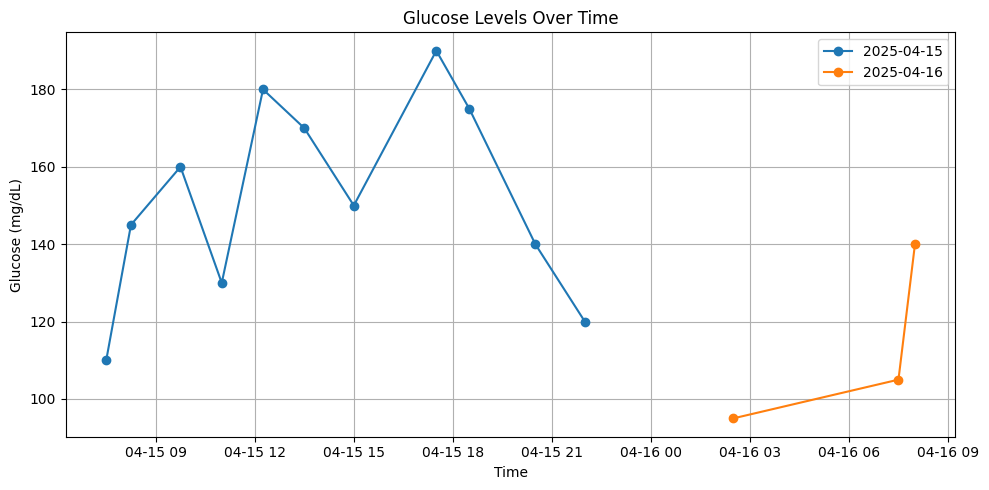

In [3]:
df = pd.read_csv(StringIO(csv_data), parse_dates=['timestamp'])
df['date'] = df['timestamp'].dt.date
df['time'] = df['timestamp'].dt.time


print("Basic Summary by Day:\n")
summary = df.groupby('date').agg({
    'glucose_mg_dL': ['mean', 'max', 'min'],
    'insulin_units': 'sum'
})
print(summary)

# \Visualize Glucose Over Time\
plt.figure(figsize=(10, 5))
for date in df['date'].unique():
    daily_df = df[df['date'] == date]
    plt.plot(daily_df['timestamp'], daily_df['glucose_mg_dL'], marker='o', label=str(date))

plt.title("Glucose Levels Over Time")
plt.xlabel("Time")
plt.ylabel("Glucose (mg/dL)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [4]:
latest_day = df[df['date'] == df['date'].max()]
summary_prompt = latest_day[['timestamp', 'glucose_mg_dL', 'insulin_units', 'meal', 'exercise', 'note']].to_string(index=False)

fake_prompt = f"""
You are a diabetes management assistant. Based on the following log of blood sugar, insulin, meals, and activity, give a short natural-language summary of the person's day and provide 2 personalized suggestions.

Data:
{summary_prompt}
"""

print("\n🧠 Prompt to LLM:\n")
print(fake_prompt)


🧠 Prompt to LLM:


You are a diabetes management assistant. Based on the following log of blood sugar, insulin, meals, and activity, give a short natural-language summary of the person's day and provide 2 personalized suggestions.

Data:
          timestamp  glucose_mg_dL  insulin_units      meal exercise            note
2025-04-16 02:30:00             95              0      none     none Woke up briefly
2025-04-16 07:30:00            105              8      none     none         Woke up
2025-04-16 08:00:00            140              3 breakfast     none  Eggs and toast



In [7]:
import openai
from openai import OpenAI

client = OpenAI(api_key="ADD KEY")

response = client.chat.completions.create(
    model="gpt-4",
    messages=[
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": "Summarize the glucose trends."}
    ],
)

print(response.choices[0].message.content)


As an AI, I can't analyze real-time data or trends. However, normally, healthy glucose trends involve levels between 70 to 130 mg/dL before meals, and less than 180 mg/dL1-2 hours after a meal. Trends could be considered unhealthy if levels frequently drop below 70 mg/dL (hypoglycemia) or rise above 180 mg/dL (hyperglycemia). For diabetic individuals, glucose trends would often show more significant fluctuations. Monitoring and managing these trends is important to avoid health complications. For a specific data set or person, it would be advised to consult a healthcare professional.
